Introduction
========

This tutorial requires simbench and RLLib, which is not included in the pandapower_env package.

Imports
=========

In [1]:
import pandapower as pp
from pandapower.networks import case2869pegase, case118, case14
import pandapower.plotting as plot

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import copy

import simbench

In [2]:
from pandapower_env.substation.create_double_busbar_substation import (
    n_assignable_elements_in_bus,
    create_all_double_busbar_substations,
    can_convert_to_n_busbar_substation,
)

from pandapower_env.substation.plot_double_busbar_substation import (
    create_double_busbar_plotting_net,
    separate_substation_buses_visually,
)

from pandapower_env.substation.double_busbar_substation import (
    get_list_of_closed_and_open_substation_switches,
)

from pandapower_env.toolbox.plotting_helpers import (
    calculate_externals_locations,
    create_geo_column_from_xy,
    create_xy_columns_from_geo,
    create_bus2bus_geodata,
    plot_all_peripherals,
    label_lines,
    label_buses,
    label_substations,
)

from pandapower_env.environments.gym_env_pp import BaseEnvPP

Load the network
=========

In [3]:
# net = case2869pegase()
net = case14()
vthresh = 0.0  # 110. # 380.

net.line["vn_kv"] = pd.merge(
    net.line, net.bus, left_on="from_bus", right_index=True, how="left"
)["vn_kv"]

net.bus["nlines"] = 0.0
for bus in net.bus.index.tolist():
    net.bus.loc[bus, "n_elements"] = n_assignable_elements_in_bus(net, bus)
    net.bus.loc[bus, "is_dbbs"] = can_convert_to_n_busbar_substation(net, bus)

example_substations = net.bus[net.bus["is_dbbs"] == True].index.tolist()

# Geodata taken from Grid 2 Op for familiarity.
# This is the "x", "y" Dataframe that we are familiar with from Pandapower 2.0
df_bus_geodata = pd.DataFrame(
    {
        0: [-280.0, -81.0],
        1: [-100.0, -270.0],
        2: [366.0, -270.0],
        3: [366.0, -54.0],
        4: [-64.0, -54.0],
        5: [-64.0, 54.0],
        6: [450.0, 0.0],
        7: [550.0, 0.0],
        8: [326.0, 54.0],
        9: [222.0, 108.0],
        10: [79.0, 162.0],
        11: [-170.0, 270.0],
        12: [-64.0, 270.0],
        13: [222.0, 216.0],
    },
    index=["x", "y"],
).T

net.bus.geo = create_geo_column_from_xy(df_bus_geodata)

calculate_externals_locations(net, offset=55)

orig_net = copy.deepcopy(net)

Plot the Network
========

<Axes: >

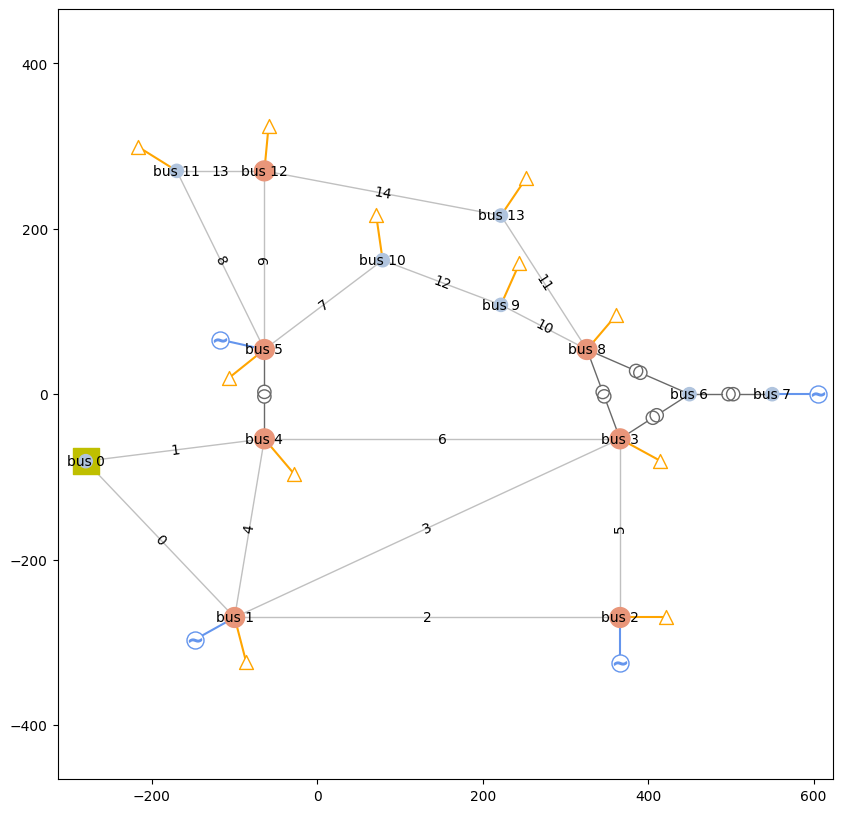

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

bus_size = 8

all_collections = []
line_c = plot.create_line_collection(
    orig_net,
    orig_net.line[orig_net.line["vn_kv"] >= vthresh].index,
    color="silver",
    zorder=2,
    linewidths=1,
)
bus_c = plot.create_bus_collection(
    orig_net,
    orig_net.bus[orig_net.bus["vn_kv"] >= vthresh].index,
    color="lightsteelblue",
    size=bus_size,
    zorder=3,
)
sub_c = plot.create_bus_collection(
    orig_net, example_substations, color="darksalmon", size=bus_size * 1.5, zorder=4
)
trafo_c = plot.create_trafo_collection(
    orig_net,
    orig_net.trafo[orig_net.trafo["vn_lv_kv"] >= vthresh].index,
    color="dimgray",
    size=bus_size,
    linewidths=1,
)
ext_c = plot.create_bus_collection(
    orig_net,
    orig_net.ext_grid.index,
    patch_type="rect",
    size=bus_size * 2.0,
    color="y",
    zorder=2,
)
loads_c = plot.create_load_collection(orig_net, size=2 * bus_size, orientation=3.14 / 3)
gen_c = plot.create_gen_collection(
    orig_net, size=2 * bus_size, orientation=2 * 3.14 / 3
)
for c in [line_c, bus_c, sub_c, trafo_c, ext_c]:  # ,loads_c,gen_c] :
    if c != None:
        all_collections.append(c)

plot_all_peripherals(orig_net, ax)

label_buses(orig_net, ax, labels=["bus {}".format(bus) for bus in net.bus.index])
label_lines(orig_net, ax)
plot.draw_collections(all_collections, ax=ax, axes_visible=(True, True))

Create the double-busbar substation 
==========

In [5]:
create_all_double_busbar_substations(net)

In [6]:
net.multi_bb_substation

,bus_0,bus_1,b01_switch,connected_buses,n_busbars_in_substation,element_type,connected_elements,b0_switches,b1_switches
0,1,14,0,"[15, 16, 17, 18, 19, 20]",2,"[line, line, line, line, load, gen]","[0, 2, 3, 4, 0, 0]","[1, 3, 5, 7, 9, 11]","[2, 4, 6, 8, 10, 12]"
1,2,21,13,"[22, 23, 24, 25]",2,"[line, line, load, gen]","[2, 5, 1, 1]","[14, 16, 18, 20]","[15, 17, 19, 21]"
2,3,26,22,"[27, 28, 29, 30, 31, 32]",2,"[line, line, line, trafo, trafo, load]","[3, 5, 6, 0, 1, 2]","[23, 25, 27, 29, 31, 33]","[24, 26, 28, 30, 32, 34]"
3,4,33,35,"[34, 35, 36, 37, 38]",2,"[line, line, line, trafo, load]","[1, 4, 6, 2, 3]","[36, 38, 40, 42, 44]","[37, 39, 41, 43, 45]"
4,5,39,46,"[40, 41, 42, 43, 44, 45]",2,"[line, line, line, trafo, load, gen]","[7, 8, 9, 2, 4, 2]","[47, 49, 51, 53, 55, 57]","[48, 50, 52, 54, 56, 58]"
5,8,46,59,"[47, 48, 49, 50, 51]",2,"[line, line, trafo, trafo, load]","[10, 11, 1, 4, 5]","[60, 62, 64, 66, 68]","[61, 63, 65, 67, 69]"
6,12,52,70,"[53, 54, 55, 56]",2,"[line, line, line, load]","[9, 13, 14, 9]","[71, 73, 75, 77]","[72, 74, 76, 78]"


Plot a double-busbar substation
=======

The supplied network uses an outdated geodata format. Please update your geodata by
running `pandapower.plotting.geo.convert_geodata_to_geojson(net)`


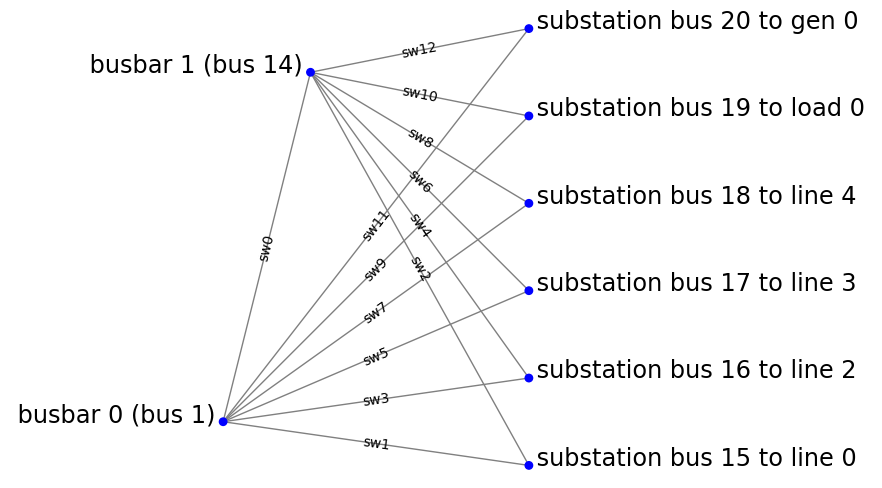

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

tmp_net = create_double_busbar_plotting_net(net, 0)

plot.simple_plot(tmp_net, ax=ax, show_plot=False)

for bus in tmp_net.bus.index.tolist():
    ax.text(
        tmp_net.bus_geodata.loc[bus, "x"],
        tmp_net.bus_geodata.loc[bus, "y"],
        " " + tmp_net.bus.loc[bus, "name"] + " ",
        zorder=5,
        size="xx-large",
        transform=ax.transData,
        ha=("right" if (bus < 2) else "left"),
    )

label_lines(tmp_net, ax, labels=["sw{}".format(ln) for ln in tmp_net.line.index])

Define an action space
=======

In [8]:
dict_actions = [
    {"action": 0, "substations": [], "states": [], "open_lines": []},
    {"action": 1, "substations": [0], "states": ["0x110101"], "open_lines": []},
    {
        "action": 2,
        "substations": [0, 1],
        "states": ["0x101101", "0x1100"],
        "open_lines": [2, 5],
    },
    {"action": 2, "substations": [], "states": [], "open_lines": [5]},
]

In [9]:
sub, state = 0, "0x101011"

switches_closed, switches_open = get_list_of_closed_and_open_substation_switches(net, sub, state)

print("Closed substation switches:", switches_closed)
print("Open substation switches:", switches_open)

Closed substation switches: [3, 7, 2, 6, 10, 12]
Open substation switches: [0, 1, 5, 9, 11, 4, 8]


In [10]:
df_actions = pd.DataFrame(dict_actions)
df_actions.index.name = None

Plot action
==============

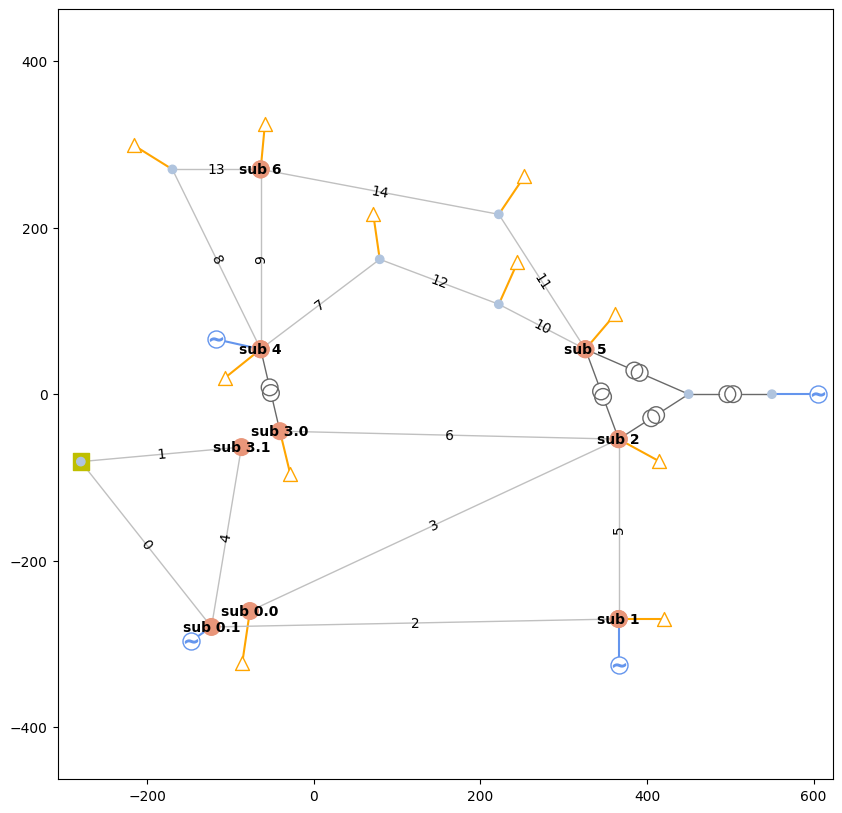

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

bus_size = 5

action_dict = {
    "action": 1,
    "substations": [0, 3],
    "states": ["0x110101", "0x11000"],
    "open_lines": [],
}
bus_geo, line_geos = separate_substation_buses_visually(
    net, action_dict, r_split_bus=25
)

line_c = plot.create_line_collection(
    net,
    net.line[net.line["vn_kv"] >= vthresh].index,
    color="silver",
    zorder=2,
    linewidths=1,
    line_geodata=line_geos,
)
bus_c = plot.create_bus_collection(
    net,
    net.bus[net.bus["vn_kv"] >= vthresh].index,
    color="lightsteelblue",
    size=bus_size,
    zorder=3,
    bus_geodata=create_xy_columns_from_geo(bus_geo),
)
sub_c = plot.create_bus_collection(
    net,
    net.multi_bb_substation[["bus_0", "bus_1"]].values.flatten().tolist(),
    color="darksalmon",
    size=bus_size * 2.0,
    zorder=4,
    bus_geodata=create_xy_columns_from_geo(bus_geo),
)
trafo_c = plot.create_trafo_collection(
    net,
    net.trafo.index,
    net.trafo[net.trafo["vn_lv_kv"] >= vthresh].index,
    color="dimgray",
    size=bus_size * 2,
    linewidths=1,
    bus_geodata=bus_geo,
)
ext_c = plot.create_bus_collection(
    net,
    net.ext_grid.index,
    patch_type="rect",
    size=bus_size * 2.0,
    color="y",
    zorder=2,
    bus_geodata=create_xy_columns_from_geo(bus_geo),
)

all_collections = []
for c in [line_c, sub_c, trafo_c, ext_c, bus_c]:
    if c != None:
        all_collections.append(c)

plot_all_peripherals(net, ax, bus_geodata=bus_geo)
plot.draw_collections(all_collections, ax=ax, axes_visible=(True, True))

label_lines(net, ax, bus_geodata=bus_geo)

sub_labels = ["sub {}".format(i_sub) for i_sub in net.multi_bb_substation.index]
label_substations(net, ax, bus_geodata=bus_geo, labels=sub_labels)

Grab some timeseries profiles from Simbench
=========

We need some timeseries profiles. Here is some quick code to grab those profiles (do not want to belabor the point here).

We create a `net.profiles` Dataframe to emulate the structure of the simbench grid.

In [12]:
net.profiles = simbench.get_all_simbench_profiles(0)

In [13]:
def get_profile_names(df_profile):
    """
    Quick function to get the names of each of the profiles offered by Simbench
    """
    return (
        df_profile.columns[1:]
        .to_series()
        .apply(lambda x: x.replace("_pload", "").replace("_qload", ""))
        .unique()
    )

In [14]:
# Randomly select some profiles to load.
rng = np.random.default_rng(seed=12345)
net.load["profile"] = rng.choice(get_profile_names(net.profiles["load"]), len(net.load))
net.gen["profile"] = rng.choice(
    get_profile_names(net.profiles["powerplants"]), len(net.gen)
)
# net.sgen['profile'] = rng.choice(get_profile_names(net.profiles['renewables']),len(net.sgen))

In [15]:
# Make sure loads, generators each have unique names
net.gen["name"] = net.gen.index.to_series().apply(lambda x: f"Generator {x}")
net.sgen["name"] = net.sgen.index.to_series().apply(lambda x: f"Static Generator {x}")
net.load["name"] = net.load.index.to_series().apply(lambda x: f"Load {x}")

Set up the simple example RL Environment (base class)
=======

The functions `load_action`, `create_observation` and `calculate_reward` must be implemented
by the user!

In [16]:
try:
    my_env = BaseEnvPP(
        env_config={
            "n_episodes": 10,
            "episode_length": 10,
            "net": net,
            "nminus1": False,
        }
    )
except TypeError as e:
    print(e)
    pass

Can't instantiate abstract class BaseEnvPP without an implementation for abstract methods 'calculate_reward', 'create_observation', 'load_action'


Set up a custom environment
===========

In [17]:
def empty_custom_env(BaseEnvPP):

    def __init__(self, env_config):
        super().__init__(env_config)
        return

    def load_action(self, action):
        pass

    def create_observation(self, net):
        pass

    def calculate_reward(self, net):
        pass

In [18]:
from gymnasium import spaces
from pandapower_env.substation.double_busbar_substation import (
    get_list_of_closed_and_open_substation_switches,
)


class my_custom_env(BaseEnvPP):

    def __init__(self, env_config):
        """
        Initialize the my_custom_env environment.
        Note that env_config must be a serializable dict in order to be e.g. used in a RLLib-style
        environment that sends jobs to a batch system.

        Required configuration keys in env_config:
         - 'net' (from gym_env_pp): pp.pandapowerNet or path to pandapower network file
         - 'n_episodes' (from gym_env_pp): Number of episodes to run
         - 'action_space': A dictionary corresponding to the action space

        :param env_config: environment configuration
        :type env_config: dict
        """
        super().__init__(env_config)

        self.df_actions = self.create_actions_df(env_config["action_space"])

        # Define action space:
        self.action_space = spaces.Discrete(len(self.df_actions))

        # Define observation space:
        self.observation_space = self.define_observation_space()

        return

    def calculate_open_and_closed_switches(self, dict_actions):
        """
        Add key-value pairs 'open_switches' and 'closed_switches' to the actions dictionary
        to determine the switch operations that correspond to the substation action.
        """

        for action in dict_actions:
            action["open_switches"] = []
            action["closed_switches"] = []
            for i_sub, state in zip(action["substations"], action["states"]):
                closed_switches, open_switches = get_list_of_closed_and_open_substation_switches(
                    self.net, i_sub, state
                )
                action["open_switches"].extend(open_switches)
                action["closed_switches"].extend(closed_switches)

        return

    def create_actions_df(self, dict_actions):

        self.calculate_open_and_closed_switches(dict_actions)

        df_actions = pd.DataFrame(dict_actions)
        df_actions = df_actions[
            [
                "substations",
                "states",
                "open_switches",
                "closed_switches",
            ]
        ]
        df_actions.index.name = None

        return df_actions

    def load_action(self, action):

        # reset all switches in the network
        self.net.switch["closed"] = True

        open_switches = self.df_actions.loc[action, "open_switches"]
        self.net.switch.loc[open_switches, "closed"] = False
        return

    def define_observation_space(self):

        # The example here is the line loading (%) of each line
        return spaces.Box(
            low=0, high=200, shape=(len(self.net.line),), dtype=np.float32
        )

    def create_observation(self):
        """
        This function will be called by the "step" function.
        """

        observation = np.clip(self.net.res_line["loading_percent"], 0, 200).tolist()

        return observation

    def calculate_reward(self):
        """
        This is a simple example of a reward: minimizing the loading of
        all of the lines (trying to prevent one or more lines from overloading).

        :param net: the pandapower network
        :type net: pandapowerNet
        :return: reward
        :rtype: float
        """

        max_loading = self.net.res_line["loading_percent"].max()
        reward = -max_loading

        return reward

In [19]:
my_config = {
    "net": net,
    "n_episodes": 10,
    "episode_length": 10,
    "action_space": dict_actions,
    "nminus1": False,
}
env = my_custom_env(my_config)

In [20]:
env.df_actions

,substations,states,open_switches,closed_switches
0,[],[],[],[]
1,[0],[0x110101],"[0, 1, 3, 7, 11, 6, 10]","[5, 9, 2, 4, 8, 12]"
2,"[0, 1]","[0x101101, 0x1100]","[0, 1, 5, 7, 11, 4, 10, 13, 14, 16, 19, 21]","[3, 9, 2, 6, 8, 12, 18, 20, 15, 17]"
3,[],[],[],[]


In [21]:
## Reset the environment
print("Resetting")
state = env.reset()
env.render()

## Example loop to test the environment
print("Starting an episode.")
done = False
while not done:
    env.render()
    action = env.action_space.sample()  # Randomly choose action
    state, reward, terminated, truncated, _ = env.step(action)
    print("Action: {} Reward: {:.2f}".format(action, reward))
    if truncated or terminated:
        break

env.close()

Resetting
Starting an episode.


Action: 1 Reward: -0.93
Action: 1 Reward: -0.97
Action: 3 Reward: -1.09
Action: 3 Reward: -1.04
Action: 1 Reward: -0.92
Action: 3 Reward: -1.04
Action: 3 Reward: -1.07
Action: 0 Reward: -1.01
Action: 2 Reward: -0.63
Action: 3 Reward: -1.00


Train an agent using RLLib
======

In [22]:
# config = (  # 1. Configure the algorithm,
#    PPOConfig()
#    .environment(env=my_custom_env,env_config={my_config})
#    .env_runners(num_env_runners=1)
#    .framework("torch")
#    .training(model={"fcnet_hiddens": [64, 64]})
#    .evaluation(evaluation_num_env_runners=1,evaluation_interval=1)
# )
#
# algo = config.build()  # 2. build the algorithm,

Suggested Tasks:
=========

 - Get your environment set up with the example `my_custom_env`
 - Take a look at the results of net.res_line, net.res_bus to see which might be useful as observations
 - Extend / write a new observation space that is compatible with GNNs
 - Create a more interesting action space (e.g. a complete action space)
 - Integrate the environment into RLLib or another training package
 - Train a GNN agent based on the environment.

**End goal: A working environment and a trained GNN agent (prototype)**